In [ ]:
 # Mount Google Drive to access datasets, models, or other files stored in Drive.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Import all requried libraries.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, mean_squared_error
from sklearn.metrics import precision_score, recall_score, f1_score
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import seaborn as sns
import tensorflow as tf

In [ ]:
#Connect to OCT dataset folder in Drive.

dataset_path = '/content/drive/My Drive/OCT_Dataset'

In [ ]:
# Initialise ImageDataGenerator for preprocessing and dataset splitting.
# Rescale: Normalises pixel values from [0, 255] to [0, 1] to improve model convergence

data_gen = ImageDataGenerator
 (
    rescale=1./255, # Normalises pixel values from [0, 255] to [0, 1] to improve model convergence.

    rotation_range=15, # Randomly rotate images by up to 15 degrees.

    width_shift_range=0.1, # Randomly shift images horizontally by up to 10% of the width.

    height_shift_range=0.1,# Randomly shift images vertically by up to 10% of the height.

    shear_range=0.1, # Apply random shear transformations up to 10%.

    zoom_range=0.1, # Randomly zoom in or out by up to 10%.

    horizontal_flip=True, # Randomly flip images horizontally.

    validation_split=0.2 # Reserves 20% of the data for validation.
)

In [ ]:
# Prepare the training dataset using the data generator.
# Images are resized to 128x128 pixels, loaded in batches of 32, and labels are one-hot encoded. Only the 'training' subset is loaded.

train_data = data_gen.flow_from_directory
 (
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 623 images belonging to 3 classes.


In [ ]:
# Prepare the validation dataset using the same configuration.
# Only the 'validation' subset is loaded.

val_data = data_gen.flow_from_directory
 (
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 155 images belonging to 3 classes.


In [ ]:
# Load the VGG16 model pre-trained on ImageNet, excluding its top classification layers.
# The input shape is set to 128x128x3 to match the dataset dimensions.

base_model_vgg = VGG16(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
base_model_vgg.trainable = False  # Freeze base layers

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_vgg = models.Sequential
 ([

    # Base Model: Pre-trained VGG16 feature extractor (frozen weights).
    base_model_vgg,

    # Flatten Layer: Converts 3D feature maps to 1D feature vectors.
    # for dense layer processing (shape transition: (None, 4, 4, 512) → (None, 8192).
    layers.Flatten(),

    # Dense Layer: 256-unit fully-connected layer with ReLU activation.
    #    - First trainable layer after feature extraction.
    #    - 256 units chosen as compromise between complexity and overfitting.
    layers.Dense(256, activation='relu'),

    # Dropout Layer: 50% dropout for regularisation.
    #    - Randomly deactivates half the neurons during training.
    #    - Reduces overfitting to training data.
    layers.Dropout(0.5),

    # Output Layer: Softmax classification layer.
    #    - Units match number of classes in dataset (from train_data).
    #    - Outputs probability distribution over classes.
    layers.Dense(train_data.num_classes, activation='softmax')
])

In [ ]:
# Configure model training parameters via compile():

#   - optimizer: Adam optimizer with learning rate=0.001 (default recommended).
#     - Adaptive momentum-based gradient descent.

#   - loss: Categorical crossentropy (standard for multi-class classification).
#     - Matches softmax output layer.

#   - Metrics: Track accuracy during training/validation.

model_vgg.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [ ]:
# Learning Rate Scheduling:
#   - Reduces LR by 50% (factor=0.5) when val_loss plateaus for 3 epochs.
#   - Allows adaptive refinement while avoiding overshooting minima.

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# Early Stopping:
#   - Halts training if val_loss doesn't improve for 5 epochs.
#   - Restores best weights post-training to prevent overfitting.

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

In [ ]:
# Execute model training:

history_vgg = model_vgg.fit(
    train_data, # Preprocessed training batches (from ImageDataGenerator).

    epochs=20, # Maximum training iterations (may stop earlier via callbacks).

    validation_data=val_data, # Held-out validation set for monitoring.

    callbacks=[lr_scheduler, early_stopping] # Dynamic LR adjustment + early stopping.
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 251s 12s/step - accuracy: 0.4718 - loss: 1.4282 - val_accuracy: 0.7935 - val_loss: 0.6052 - learning_rate: 0.0010
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 197s 10s/step - accuracy: 0.7222 - loss: 0.6908 - val_accuracy: 0.8258 - val_loss: 0.5251 - learning_rate: 0.0010
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 195s 10s/step - accuracy: 0.7746 - loss: 0.5749 - val_accuracy: 0.8710 - val_loss: 0.4151 - learning_rate: 0.0010
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 192s 10s/step - accuracy: 0.7930 - loss: 0.4988 - val_accuracy: 0.8774 - val_loss: 0.3797 - learning_rate: 0.0010
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 198s 10s/step - accuracy: 0.8113 - loss: 0.4701 - val_accuracy: 0.8710 - val_loss: 0.3385 - learning_rate: 0.0010
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 196s 10s/step - accuracy: 0.8259 - loss: 0.4424 - val_accuracy: 0.8968 - val_loss: 0.3337 - learning_rate: 0.0010
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 198s 9s/step - accuracy: 0.8392 - loss: 0.4057 - v

In [ ]:
# Fine-tuning Phase: Unfreeze select layers for targeted feature adaptation.

base_model_vgg.trainable = True

# Freeze all layers except the last 4 convolutional blocks.
# - Allows high-level feature adaptation while preserving low-level patterns.
# - Reduces computational cost and overfitting risk.

for layer in base_model_vgg.layers[:-4]:  # Freeze all layers except the last 4.
    layer.trainable = False

In [ ]:
# Recompile model with lower learning rate (1e-4) for fine-tuning:

# - 10x smaller than initial training (0.0001 vs 0.001 in VGG16_v1).
# - Prevents destructive updates to pre-trained weights.

model_vgg.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [ ]:
# Execute fine-tuning training:
# Uses same callbacks as initial training (LR reduction + early stopping).
# Increased from 10 epochs in VGG16_v1 to 20 epochs for sufficient convergence.
# Monitors validation metrics to prevent overfitting.

fine_tune_history = model_vgg.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=[lr_scheduler, early_stopping]
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 227s 11s/step - accuracy: 0.6855 - loss: 1.1728 - val_accuracy: 0.8065 - val_loss: 0.4472 - learning_rate: 1.0000e-04
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 220s 11s/step - accuracy: 0.8345 - loss: 0.4228 - val_accuracy: 0.8839 - val_loss: 0.2952 - learning_rate: 1.0000e-04
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 219s 11s/step - accuracy: 0.9056 - loss: 0.2989 - val_accuracy: 0.8903 - val_loss: 0.2884 - learning_rate: 1.0000e-04
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 219s 11s/step - accuracy: 0.9093 - loss: 0.2595 - val_accuracy: 0.8710 - val_loss: 0.2859 - learning_rate: 1.0000e-04
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 221s 11s/step - accuracy: 0.9035 - loss: 0.2685 - val_accuracy: 0.9548 - val_loss: 0.1136 - learning_rate: 1.0000e-04
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 220s 11s/step - accuracy: 0.9483 - loss: 0.1430 - val_accuracy: 0.9742 - val_loss: 0.0777 - learning_rate: 1.0000e-04
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 219s 11s/step - accuracy: 

In [ ]:
# Model Evaluation:
# Extract true labels from validation generator.
val_labels = val_data.classes

# Convert to class indices (argmax of probabilities).
val_preds = np.argmax(model_vgg.predict(val_data), axis=-1)

# Get human-interpretable class names from generator mapping.
class_names = list(val_data.class_indices.keys())

5/5 ━━━━━━━━━━━━━━━━━━━━ 38s 8s/step


In [ ]:
# Compute Metrics
accuracy = np.mean(val_preds == val_labels)

# Precision, Recall, and F1-score computed for each class individually.
#'zero_division=0' avoids division errors in case of no predicted samples for a class.

precision = precision_score(val_labels, val_preds, average=None, zero_division=0)
recall = recall_score(val_labels, val_preds, average=None, zero_division=0)
f1 = f1_score(val_labels, val_preds, average=None, zero_division=0)

mse = mean_squared_error(val_labels, val_preds)

auc = roc_auc_score(
    tf.keras.utils.to_categorical(val_labels),
    model_vgg.predict(val_data),
    multi_class='ovr'
    )

5/5 ━━━━━━━━━━━━━━━━━━━━ 38s 8s/step


In [ ]:
# Organise overall performance metrics into a table for better presentation.

performance_data =
 {
    "Metric": ["Accuracy", "Mean Squared Error (MSE)", "Area Under the ROC Curve (AUC)"],
    "Value": [round(accuracy, 2), round(mse, 2), round(auc, 2)]
}

In [ ]:
# Display the overall evaluation metrics in a tabular format.

performance_table = pd.DataFrame(performance_data)
print("\nOverall Performance Metrics:")
print(performance_table.to_string(index=False))

In [ ]:
# Compile class-wise precision, recall, and F1-score into a structured table.
# Rounding each metric to two decimal places for clarity.

class_metrics =
 {
    "Class": class_names,
    "Precision": [round(p, 2) for p in precision],
    "Recall": [round(r, 2) for r in recall],
    "F1-Score": [round(f, 2) for f in f1]
}


Overall Performance Metrics:
                        Metric  Value
                      Accuracy   0.34
      Mean Squared Error (MSE)   1.92
Area Under the ROC Curve (AUC)   0.50


In [ ]:
# Display the class-wise evaluation metrics.

class_metrics_table = pd.DataFrame(class_metrics)
print("\nClass-wise Performance Metrics:")
print(class_metrics_table.to_string(index=False))


Class-wise Performance Metrics:
Class  Precision  Recall  F1-Score
  AMD       0.41    0.41      0.41
  DME       0.05    0.05      0.05
   NO       0.35    0.35      0.35


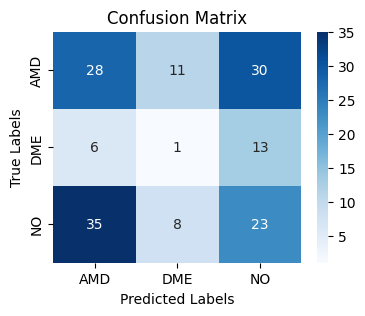

In [ ]:
# Generate and visualise the confusion matrix to assess classification performance.
# Rows represent true labels; columns represent predicted labels.

conf_matrix = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()